<a href="https://colab.research.google.com/github/YoungHyunKoo/UHI_SA_GEE/blob/main/MODIS_Heat_Island.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### *Python programming for Google Earth Engine*
# **Week 2-2. Time Series of MODIS temperature for Heat Island**

# **Install necessary library**

In [ ]:
# Install geemap library
# !pip install geemap

# **Import necessary libraries**

In [1]:
# Import geemap library
import geemap
import ee
import os

In [2]:
# Import ee library
import ee

try:
  # Initialize with your own project.
  ee.Initialize(project = "utsa-spring2024")

except:
  # Authenticate
  ee.Authenticate()
  # Initialize with your own project.
  ee.Initialize(project = "utsa-spring2024")

In [3]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
from tqdm import tqdm
from scipy import stats
import os, glob

# **Time series of *DAY* temperature changes (Aqua)**

We will see the temporal changes of surface temperatures around Bexar county area using MODIS temperature data.

Aqua passing time - 1:30 pm

In [4]:
# Region of interst: Bexar county
Bexar = ee.FeatureCollection('TIGER/2018/Counties').filter(ee.Filter.eq("NAME", "Bexar"))

# MODIS Aqua Day data (1:30 pm)
col = ee.ImageCollection("MODIS/061/MYD11A2").select("LST_Day_1km").filterDate('2000-01-01', '2026-01-01')
grid = Bexar.geometry().coveringGrid(col.mean().projection(), 1000)

# Downtown & suburban area
downtown = ee.Geometry.Point([-98.49, 29.425]).buffer(5000);
sub_urban = Bexar.geometry().difference(right=downtown);

# Road & non-road area
roads = ee.FeatureCollection("TIGER/2016/Roads")\
.filter(ee.Filter.Or(ee.Filter.eq("mtfcc", "S1100"), ee.Filter.eq("mtfcc", "S1200"))).filterBounds(Bexar)

road_buf = roads.geometry().buffer(1000).intersection(Bexar);
non_road = Bexar.geometry().difference(right=road_buf);

# Landcover data
nlcd = ee.ImageCollection("USGS/NLCD_RELEASES/2021_REL/NLCD")\
.filter(ee.Filter.eq('system:index', '2021')).first();
landcover = nlcd.select('landcover').clip(grid);
# Census tract data
tract = ee.FeatureCollection("TIGER/2020/TRACT").filterBounds(Bexar).filter(ee.Filter.eq("COUNTYFP", "029"))

# See major landcover
majorlc = landcover.reduceRegions(collection=tract, reducer=ee.Reducer.mode())

In [5]:
## Reduce region in tract level
majorlc = landcover.reduceRegions(collection=tract, reducer=ee.Reducer.mode())
df = geemap.ee_to_gdf(majorlc).set_crs('EPSG:4326')
df["mode"] = np.around(df["mode"]).astype(int)

land_poly = geemap.geopandas_to_ee(df)

In [ ]:
## Reduce region in grid level
grid = Bexar.geometry().coveringGrid(col.mean().projection(), 1000)

majorlc = landcover.reduceRegions(collection=grid, reducer=ee.Reducer.mode())
df = geemap.ee_to_gdf(majorlc).set_crs('EPSG:4326')
df["mode"] = np.around(df["mode"]).astype(int)

land_poly = geemap.geopandas_to_ee(df)

In [8]:
# Developed
d_op = land_poly.filter(ee.Filter.eq("mode", 21)) # Developed: open space
d_li = land_poly.filter(ee.Filter.eq("mode", 22)) # Developed: low intensity
d_mi = land_poly.filter(ee.Filter.eq("mode", 23)) # Developed: medium intensity
d_hi = land_poly.filter(ee.Filter.eq("mode", 24)) # Developed: high intensity

d_low = land_poly.filter(ee.Filter.Or(ee.Filter.eq("mode", 21), ee.Filter.eq("mode", 22))) # Open & low developed
d_high = land_poly.filter(ee.Filter.Or(ee.Filter.eq("mode", 23), ee.Filter.eq("mode", 24))) # Open & low developed

# Forest
forest = land_poly.filter(ee.Filter.Or(ee.Filter.eq("mode", 41), ee.Filter.eq("mode", 42), ee.Filter.eq("mode", 43)))
# Forest: deciduous and evergreen forest

# Shrub & Grass & Barren land
shrub = land_poly.filter(ee.Filter.Or(ee.Filter.eq("mode", 52), ee.Filter.eq("mode", 31), ee.Filter.eq("mode", 71)))

# Crops
crops = land_poly.filter(ee.Filter.Or(ee.Filter.eq("mode", 81), ee.Filter.eq("mode", 82)))

# Wetland
wetland = land_poly.filter(ee.Filter.eq("mode", 90))

# Water
water = land_poly.filter(ee.Filter.eq("mode", 11))

In [ ]:
# Image collection for summer months (6, 7, 8)
col06 = col.filter(ee.Filter.stringContains('system:index', '_06_'))
col07 = col.filter(ee.Filter.stringContains('system:index', '_07_'))
col08 = col.filter(ee.Filter.stringContains('system:index', '_08_'))

col_sum = col06.merge(col07).merge(col08)

# Image collection for winter months (12, 1, 2)
col12 = col.filter(ee.Filter.stringContains('system:index', '_12_'))
col01 = col.filter(ee.Filter.stringContains('system:index', '_01_'))
col02 = col.filter(ee.Filter.stringContains('system:index', '_02_'))

col_win = col12.merge(col01).merge(col02)

In [ ]:
print("All-month images: ", col.size().getInfo())
print("Summer images: ", col_sum.size().getInfo())
print("Winter images: ", col_win.size().getInfo())

All-month images:  1080
Summer images:  284
Winter images:  280


In [ ]:
# Statistical map of all data
temp_med = col.median().multiply(0.02).clip(Bexar) # Median temperature
temp_mean = col.mean().multiply(0.02).clip(Bexar) # Mean temperature
temp_min = col.min().multiply(0.02).clip(Bexar) # Min temperature
temp_max = col.max().multiply(0.02).clip(Bexar) # Max temperature
temp_std = col.reduce(ee.Reducer.stdDev()).multiply(0.02).clip(Bexar) # Std temperature

# Statistical map of SUMMER data (JUN, JUL, AUG)
temp_med_sum = col_sum.median().multiply(0.02).clip(Bexar) # Median temperature
temp_mean_sum = col_sum.mean().multiply(0.02).clip(Bexar) # Mean temperature
temp_min_sum = col_sum.min().multiply(0.02).clip(Bexar) # Min temperature
temp_max_sum = col_sum.max().multiply(0.02).clip(Bexar) # Max temperature
temp_std_sum = col_sum.reduce(ee.Reducer.stdDev()).multiply(0.02).clip(Bexar) # Std temperature

# Statistical map of WINTER data (DEC, JAN, FEB)
temp_med_win = col_win.median().multiply(0.02).clip(Bexar) # Median temperature
temp_mean_win = col_win.mean().multiply(0.02).clip(Bexar) # Mean temperature
temp_min_win = col_win.min().multiply(0.02).clip(Bexar) # Min temperature
temp_max_win = col_win.max().multiply(0.02).clip(Bexar) # Max temperature
temp_std_win = col_win.reduce(ee.Reducer.stdDev()).multiply(0.02).clip(Bexar) # Std temperature

### Visualize image data on the map

In [ ]:
Map = geemap.Map()
Map.centerObject(Bexar, 10)

# Minimum & Maximum temperature (K) for visualization ==========================
min_val = 270
max_val = 310
## =============================================================================

visParams = {
  'min': min_val,
  'max': max_val,
  'palette': ['navy', 'blue', 'cyan', 'yellow', 'orange', 'red', 'brown'],
  'opacity': 0.8
};

empty = ee.Image().byte();
fills = empty.paint(
  featureCollection = land_poly,
  color = 'mode',
)
palette = ['FF0000', '00FF00', '0000FF'];

## You can put the image data you want to visuazlie ============================
# Map.addLayer(temp_mean_sum, visParams, "Day Temperature")
Map.addLayer(roads, {}, "Roads")
Map.addLayer(road_buf, {'color': 'black'}, "Roads buf")
Map.addLayer(non_road, {'color': 'gray'}, "Non road")
# Map.addLayer(fills, {'palette': palette, 'min': 20, 'max': 90}, 'colored fills');

Map.addLayer(d_high, {'color': 'red'}, "D hi")
Map.addLayer(d_low, {'color': 'orange'}, "D lo")
Map.addLayer(forest, {'color': 'green'}, "forest")
Map.addLayer(crops, {'color': 'brown'}, "crops")
Map.addLayer(shrub, {'color': 'blue'}, "shrub")
Map.addLayer(wetland, {'color': 'cyan'}, "wetland")
## =============================================================================

Map

In [ ]:
zip = ee.FeatureCollection("TIGER/2010/ZCTA5")

In [ ]:
nlcd = ee.ImageCollection("USGS/NLCD_RELEASES/2021_REL/NLCD")\
.filter(ee.Filter.eq('system:index', '2021')).first()

landcover = nlcd.select('landcover').clip(Bexar)

# geemap.zonal_statistics(dem, states, out_dem_stats, statistics_type='MEAN', scale=1000)

### Calculate statistics by land cover

In [6]:
# Mount to Google Drive (save files)
from google.colab import drive
drive.mount('/content/drive')

folder = "drive/MyDrive/Colab Notebooks/UHI"

Mounted at /content/drive


In [ ]:
field = 'LST_Day_1km'

def create_df_roi(img):
    dt_list = img.reduceColumns(ee.Reducer.toList(2), ['date','temp']).values().get(0)
    df_dt = pd.DataFrame(dt_list.getInfo(), columns=['date', 'temp'])
    df_dt['date'] = pd.to_datetime(df_dt['date'])
    return df_dt

def temp_total(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=Bexar, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_high(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=d_high, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_low(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=d_low, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_forest(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=forest, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_crops(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=crops, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_shrub(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=shrub, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_wetland(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=wetland, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_road(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=road_buf, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_nroad(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=non_road, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

# MODIS Aqua Day data (1:30 pm)
col = ee.ImageCollection("MODIS/061/MYD11A2").select(field).filterDate('2000-01-01', '2023-01-01')

img_total = col.map(temp_total)
img_d_high = col.map(temp_d_high)
img_d_low = col.map(temp_d_low)
img_forest = col.map(temp_forest)
img_crops = col.map(temp_crops)
img_shrub = col.map(temp_shrub)
img_wetland = col.map(temp_wetland)
img_road = col.map(temp_road)
img_nroad = col.map(temp_nroad)

# Total temperautre
df = create_df_roi(img_total)
df["month"] = pd.DatetimeIndex(df['date']).month
df["year"] = pd.DatetimeIndex(df['date']).year

# Temperature for each region
df_d_high = create_df_roi(img_d_high)
df_d_low = create_df_roi(img_d_low)
df_forest = create_df_roi(img_forest)
df_crops = create_df_roi(img_crops)
df_shrub = create_df_roi(img_shrub)
df_wetland = create_df_roi(img_wetland)
df_road = create_df_roi(img_road)
df_nroad = create_df_roi(img_nroad)

df = df.join(df_d_high.set_index("date"), on="date", lsuffix='', rsuffix='_dhi')
df = df.join(df_d_low.set_index("date"), on="date", lsuffix='', rsuffix='_dlo')
df = df.join(df_forest.set_index("date"), on="date", lsuffix='', rsuffix='_for')
df = df.join(df_shrub.set_index("date"), on="date", lsuffix='', rsuffix='_shr')
df = df.join(df_crops.set_index("date"), on="date", lsuffix='', rsuffix='_cro')
df = df.join(df_wetland.set_index("date"), on="date", lsuffix='', rsuffix='_wet')
df = df.join(df_road.set_index("date"), on="date", lsuffix='', rsuffix='_rd')
df = df.join(df_nroad.set_index("date"), on="date", lsuffix='', rsuffix='_nrd')

df.to_csv(f"{folder}/{field}_SA_2002-2022.csv")

df

,date,temp,month,year,temp_dhi,temp_dlo,temp_for,temp_shr,temp_cro,temp_wet,temp_rd,temp_nrd
0,2002-07-04,307.689243,7,2002,310.187122,310.054191,304.907428,307.279450,307.538658,307.415028,308.570141,307.190285
1,2002-07-12,305.430203,7,2002,307.678633,307.168152,304.181206,304.687350,304.407716,304.420000,306.188916,304.930701
2,2002-07-20,308.029356,7,2002,310.409090,310.026448,306.214442,307.531455,307.522915,307.912541,308.958055,307.530678
3,2002-07-28,307.811861,7,2002,309.459445,309.147483,306.352046,307.523207,307.168338,306.920000,308.427592,307.539966
4,2002-08-05,308.562791,8,2002,309.927253,309.919953,305.050100,308.566969,309.813340,308.680000,309.684197,307.813391
...,...,...,...,...,...,...,...,...,...,...,...,...
936,2022-11-25,298.781111,11,2022,300.163827,299.338988,296.465247,298.461777,299.659373,298.768477,299.663133,298.337362
937,2022-12-03,301.033402,12,2022,301.460708,300.959032,297.734541,301.274731,302.169120,301.240000,301.336352,300.838465
938,2022-12-11,295.958638,12,2022,296.900586,296.547353,293.509541,295.902219,295.843157,295.946712,296.342209,295.600653
939,2022-12-19,286.463787,12,2022,286.392030,286.281758,282.217366,286.896141,287.161426,286.840000,286.958375,286.095142


In [ ]:
field = 'LST_Day_1km'
df = pd.read_csv(f"{folder}/{field}_SA_2002-2022.csv", index_col = 0)
df['date'] = pd.to_datetime(df['date'])
df["year"] = pd.DatetimeIndex(df['date']).year
df = df[df['year'] > 2002].reset_index(drop = True)
df

,date,temp,month,year,temp_dhi,temp_dlo,temp_for,temp_shr,temp_cro,temp_wet,temp_rd,temp_nrd
0,2003-01-01,295.225166,1,2003,296.114098,295.942521,292.800000,295.169610,295.140000,295.387186,295.609600,294.718177
1,2003-01-09,291.224455,1,2003,291.700000,291.605477,289.841093,291.217865,291.398648,291.520000,291.527861,290.902231
2,2003-01-17,293.896883,1,2003,294.957439,294.957860,291.891876,293.840485,293.657943,294.300000,294.457248,293.458946
3,2003-01-25,294.340033,1,2003,296.223605,295.955975,293.782423,293.461273,293.098088,293.277774,294.835993,294.104653
4,2003-02-02,292.188526,2,2003,292.551708,292.811152,291.081115,292.196697,291.925929,292.709503,292.433712,291.924725
...,...,...,...,...,...,...,...,...,...,...,...,...
913,2022-11-25,298.781111,11,2022,300.163827,299.338988,296.465247,298.461777,299.659373,298.768477,299.663133,298.337362
914,2022-12-03,301.033402,12,2022,301.460708,300.959032,297.734541,301.274731,302.169120,301.240000,301.336352,300.838465
915,2022-12-11,295.958638,12,2022,296.900586,296.547353,293.509541,295.902219,295.843157,295.946712,296.342209,295.600653
916,2022-12-19,286.463787,12,2022,286.392030,286.281758,282.217366,286.896141,287.161426,286.840000,286.958375,286.095142


(-10.0, 55.0)

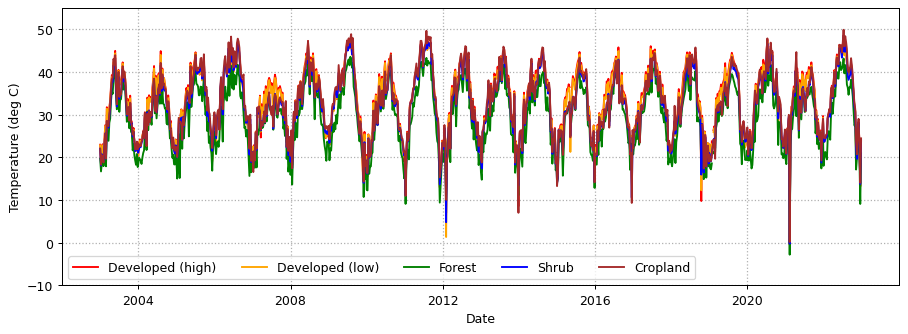

In [ ]:
plt.subplots(1,1,figsize=(12,4), dpi = 90)
plt.plot(df['date'], df['temp_dhi']-273.15, label = "Developed (high)", color = "r")
plt.plot(df['date'], df['temp_dlo']-273.15, label = "Developed (low)", color = "orange")
plt.plot(df['date'], df['temp_for']-273.15, label = "Forest", color = "g")
plt.plot(df['date'], df['temp_shr']-273.15, label = "Shrub", color = "blue")
plt.plot(df['date'], df['temp_cro']-273.15, label = "Cropland", color = "brown")
# plt.plot(df['date'], df['temp_wet'], label = "Wetland", color = "blue")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend(ncol = 5)
plt.ylabel("Temperature (deg C)")
plt.ylim(-10, 55)

(-8.0, 8.0)

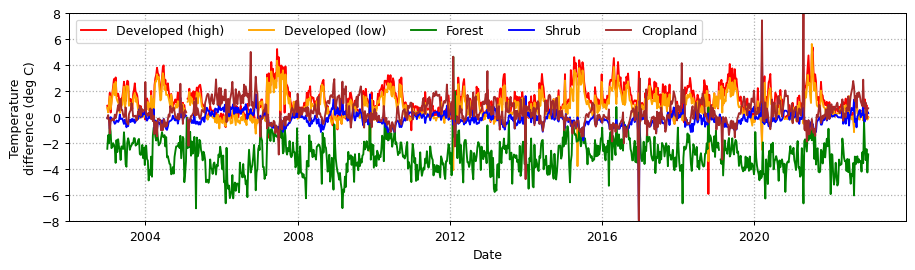

In [ ]:
plt.subplots(1,1,figsize=(12,3), dpi = 90)
plt.plot(df['date'], df['temp_dhi'] - df['temp'], label = "Developed (high)", color = "r")
plt.plot(df['date'], df['temp_dlo'] - df['temp'], label = "Developed (low)", color = "orange")
plt.plot(df['date'], df['temp_for'] - df['temp'], label = "Forest", color = "g")
plt.plot(df['date'], df['temp_shr'] - df['temp'], label = "Shrub", color = "blue")
plt.plot(df['date'], df['temp_cro'] - df['temp'], label = "Cropland", color = "brown")
# plt.plot(df['date'], df['temp_wet'] - df['temp'], label = "Wetland", color = "blue")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend(ncol = 5)
plt.ylabel("Temperature\ndifference (deg C)")
plt.ylim(-8, 8)

(-10.0, 55.0)

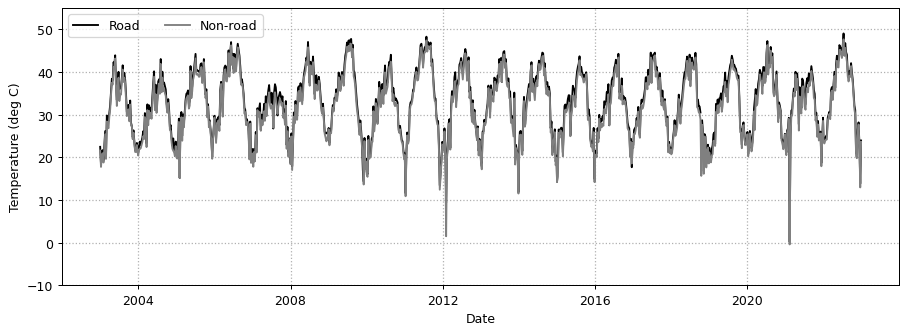

In [ ]:
plt.subplots(1,1,figsize=(12,4), dpi = 90)
plt.plot(df['date'], df['temp_rd']-273.15, label = "Road", color = "k")
plt.plot(df['date'], df['temp_nrd']-273.15, label = "Non-road", color = "gray")
# plt.plot(df['date'], df['temp_wet'], label = "Wetland", color = "blue")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend(ncol = 2)
plt.ylabel("Temperature (deg C)")
plt.ylim(-10, 55)

(-8.0, 8.0)

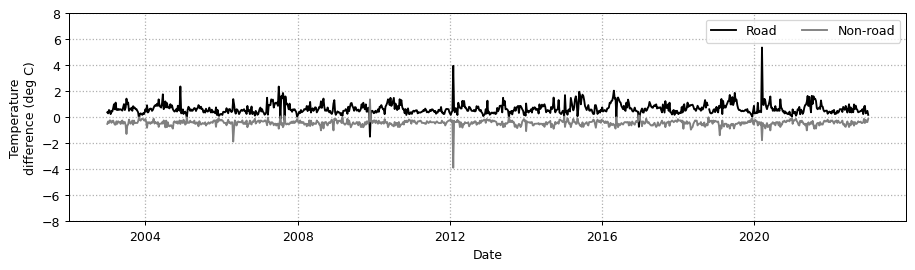

In [ ]:
plt.subplots(1,1,figsize=(12,3), dpi = 90)
plt.plot(df['date'], df['temp_rd'] - df['temp'], label = "Road", color = "k")
plt.plot(df['date'], df['temp_nrd'] - df['temp'], label = "Non-road", color = "gray")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend(ncol = 2)
plt.ylabel("Temperature\ndifference (deg C)")
plt.ylim(-8, 8)

Text(0.5, 1.0, 'Annual')

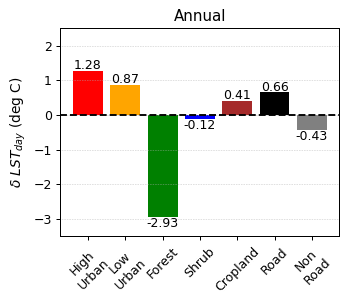

In [ ]:
def addlabels(x,y):
    for i in range(len(x)):
        if y[i] >= 0:
            plt.text(i, y[i]+0.05, "{0:.2f}".format(y[i]), ha = 'center')
        else:
            plt.text(i, y[i], "{0:.2f}".format(y[i]), ha = 'center', va = "top")

idx = (df["month"] >= 0) & (df["month"] <= 12) # Total

plt.subplots(1,1,figsize=(4,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx] - df['temp'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx] - df['temp'][idx]).mean(),
    'Forest': (df['temp_for'][idx] - df['temp'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx] - df['temp'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx] - df['temp'][idx]).mean(),
    'Road': (df['temp_rd'][idx] - df['temp'][idx]).mean(),
    'Non Road': (df['temp_nrd'][idx] - df['temp'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.xticks(rotation = 45)
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("$\delta$ $LST_{day}$ (deg C)", fontsize = 11)
plt.ylim(-3.5, 2.5)
plt.title("Annual")

Text(0.5, 1.0, 'Summer')

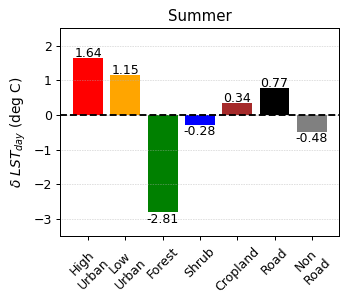

In [ ]:
idx = (df["month"] >= 6) & (df["month"] <= 8) # Summer

plt.subplots(1,1,figsize=(4,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx] - df['temp'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx] - df['temp'][idx]).mean(),
    'Forest': (df['temp_for'][idx] - df['temp'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx] - df['temp'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx] - df['temp'][idx]).mean(),
    'Road': (df['temp_rd'][idx] - df['temp'][idx]).mean(),
    'Non Road': (df['temp_nrd'][idx] - df['temp'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.xticks(rotation = 45)
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("$\delta$ $LST_{day}$ (deg C)", fontsize = 11)
plt.ylim(-3.5, 2.5)
plt.title("Summer")

Text(0.5, 1.0, 'Winter')

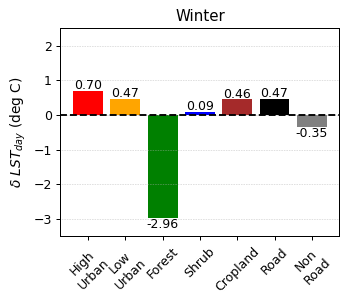

In [ ]:
idx = (df["month"] <= 2) | (df["month"] >= 12) # Winter

plt.subplots(1,1,figsize=(4,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx] - df['temp'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx] - df['temp'][idx]).mean(),
    'Forest': (df['temp_for'][idx] - df['temp'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx] - df['temp'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx] - df['temp'][idx]).mean(),
    'Road': (df['temp_rd'][idx] - df['temp'][idx]).mean(),
    'Non Road': (df['temp_nrd'][idx] - df['temp'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.xticks(rotation = 45)
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("$\delta$ $LST_{day}$ (deg C)", fontsize = 11)
plt.ylim(-3.5, 2.5)
plt.title("Winter")

In [ ]:
# Entire Bexar county time series

# Annual changes of Land cover =========================================
nlcd = ee.ImageCollection("USGS/NLCD_RELEASES/2019_REL/NLCD")
nlcd2021 = ee.ImageCollection("USGS/NLCD_RELEASES/2021_REL/NLCD")
year1 = np.array([2001, 2004, 2006, 2008, 2011, 2013, 2016, 2019, 2021])
df_lc = pd.DataFrame({'year': year1})

for i, y in tqdm(enumerate(year1)):
    if y != 2021:
      landcover = nlcd.filter(ee.Filter.eq('system:index', str(y))).first().select('landcover');
    else:
      landcover = nlcd2021.filter(ee.Filter.eq('system:index', str(y))).first().select('landcover');

    urban = landcover.expression("b('landcover') > 20 & b('landcover') < 30")
    green = landcover.expression("b('landcover') > 40 & b('landcover') < 50")

    total = landcover.reduceRegion(reducer = ee.Reducer.count(), geometry = Bexar, scale = 30)
    urban = landcover.updateMask(urban).reduceRegion(reducer = ee.Reducer.count(), geometry = Bexar, scale = 30)
    green = landcover.updateMask(green).reduceRegion(reducer = ee.Reducer.count(), geometry = Bexar, scale = 30)

    df_lc.loc[i, 'pix_total'] = total.getInfo()['landcover']
    df_lc.loc[i, 'pix_urban'] = urban.getInfo()['landcover']
    df_lc.loc[i, 'pix_green'] = green.getInfo()['landcover']

df_lc['fr_urban'] = df_lc['pix_urban'] / df_lc['pix_total'] * 100
df_lc['fr_green'] = df_lc['pix_green'] / df_lc['pix_total'] * 100
print("DONE")

# Annual changes of LST =========================================
df_temp = pd.DataFrame({})

for field in ['LST_Day_1km', 'LST_Night_1km']:
    print(field)
    col = ee.ImageCollection("MODIS/061/MYD11A2").select(field).filterDate('2000-01-01', '2026-01-01')
    year2 = np.arange(2003, 2023)

    for y in tqdm(year2):
        img = col.filterDate('{0}-01-01'.format(y), '{0}-01-01'.format(y+1)).mean() # annual mean
        img_sum = col.filterDate('{0}-06-01'.format(y), '{0}-09-01'.format(y)).mean() # summer mean
        img_win = col.filterDate('{0}-01-01'.format(y-1), '{0}-02-01'.format(y)).mean() # winter mean

        tmp = img.reduceRegion(reducer = ee.Reducer.mean(), geometry = Bexar, scale = 1000)
        tmp_sum = img_sum.reduceRegion(reducer = ee.Reducer.mean(), geometry = Bexar, scale = 1000)
        tmp_win = img_win.reduceRegion(reducer = ee.Reducer.mean(), geometry = Bexar, scale = 1000)

        df_temp.loc[y, field]  = tmp.getInfo()[field]*0.02 - 273.15
        df_temp.loc[y, field + '_sum']  = tmp_sum.getInfo()[field]*0.02 - 273.15
        df_temp.loc[y, field + '_win']  = tmp_win.getInfo()[field]*0.02 - 273.15

print("DONE")

9it [00:35,  3.97s/it]


DONE
LST_Day_1km


100%|██████████| 20/20 [00:51<00:00,  2.58s/it]


LST_Night_1km


100%|██████████| 20/20 [00:40<00:00,  2.05s/it]

DONE


In [ ]:
df_temp

,LST_Day_1km,LST_Day_1km_sum,LST_Day_1km_win,LST_Night_1km,LST_Night_1km_sum,LST_Night_1km_win
2003,30.452707,37.166210,27.979462,13.324027,21.423629,12.779751
2004,30.138600,36.444101,29.879085,13.724954,21.355713,12.670016
2005,32.861922,39.846665,29.496052,14.477612,21.922617,13.175200
2006,34.761035,43.163503,32.340822,14.175941,22.097260,13.759597
2007,29.604371,34.139818,33.653158,13.128544,20.177785,13.232713
2008,33.579674,40.612050,28.842438,12.482969,21.314357,12.196820
2009,33.811490,44.434217,32.868539,13.840632,22.313313,11.717478
2010,30.429298,38.510001,32.534597,12.901274,21.890401,12.774771
2011,34.855124,45.007555,29.506595,13.992243,23.032087,12.091767
2012,32.737711,41.172942,33.891304,14.632289,22.358444,13.280201


(2000.0, 2023.0)

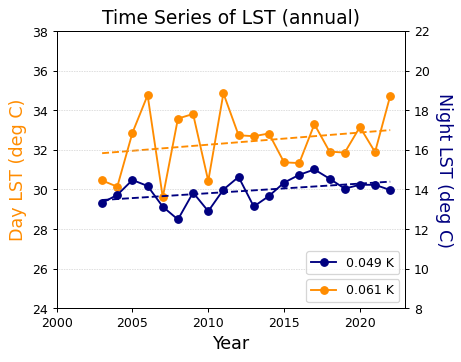

In [ ]:
def estimate_coef(x, y):
    # number of observations/points
    n = np.size(x)

    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)

    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x

    # calculating regression coefficients
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x

    return (b_0, b_1)

value1 = df_temp['LST_Day_1km'].values
value2 = df_temp['LST_Night_1km'].values

b1, a1 = estimate_coef(year2, value1)
b2, a2 = estimate_coef(year2, value2)

# create figure and axis objects with subplots()
fig,ax = plt.subplots(figsize = (5,4), dpi = 90)
# make a plot
ax.plot(year2, value1, color="darkorange", marker="o", label = "{0:.3f} K".format(a1))
ax.plot(year2, a1*year2 + b1,color="darkorange", ls = "--")
# set x-axis label
ax.set_xlabel("Year", fontsize = 14)
# set y-axis label
ax.set_ylabel("Day LST (deg C)", color="darkorange", fontsize=14)
ax.set_ylim(24, 38)

# twin object for two different y-axis on the sample plot
ax2=ax.twinx()
# make a plot with different y-axis using second axis object
ax2.plot(year2, value2, color="navy",marker="o", label = "{0:.3f} K".format(a2))
ax2.plot(year2, a2*year2 + b2,color="navy", ls = "--")
ax2.set_ylabel("Night LST (deg C)",color="navy",fontsize=14, rotation = 270, va = "bottom")
ax2.set_ylim(8, 22)
plt.grid(ls = ":", lw = 0.5)
ax.legend(loc='lower right', bbox_to_anchor=(1,0))
ax2.legend(loc='lower right', bbox_to_anchor=(1,0.1))
plt.title("Time Series of LST (annual)", fontsize = 15)
plt.xlim(2000, 2023)

# plt.savefig("F:\\Heat_Island\\Plot\\Increase_{0}_total.png".format(field),
#            bbox_inches = "tight")

(2000.0, 2023.0)

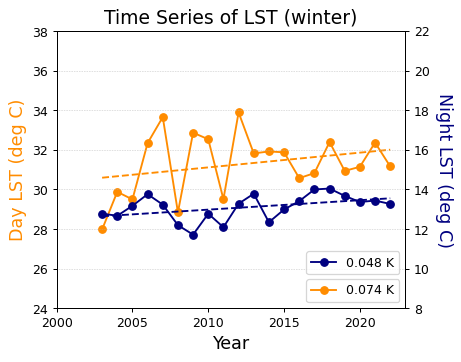

In [ ]:
value1 = df_temp['LST_Day_1km' + '_win'].values
value2 = df_temp['LST_Night_1km' + '_win'].values

b1, a1 = estimate_coef(year2, value1)
b2, a2 = estimate_coef(year2, value2)

# create figure and axis objects with subplots()
fig,ax = plt.subplots(figsize = (5,4), dpi = 90)
# make a plot
ax.plot(year2, value1, color="darkorange", marker="o", label = "{0:.3f} K".format(a1))
ax.plot(year2, a1*year2 + b1,color="darkorange", ls = "--")
# set x-axis label
ax.set_xlabel("Year", fontsize = 14)
# set y-axis label
ax.set_ylabel("Day LST (deg C)", color="darkorange", fontsize=14)
ax.set_ylim(24, 38)

# twin object for two different y-axis on the sample plot
ax2=ax.twinx()
# make a plot with different y-axis using second axis object
ax2.plot(year2, value2, color="navy",marker="o", label = "{0:.3f} K".format(a2))
ax2.plot(year2, a2*year2 + b2,color="navy", ls = "--")
ax2.set_ylabel("Night LST (deg C)",color="navy",fontsize=14, rotation = 270, va = "bottom")
ax2.set_ylim(8, 22)
plt.grid(ls = ":", lw = 0.5)
ax.legend(loc='lower right', bbox_to_anchor=(1,0))
ax2.legend(loc='lower right', bbox_to_anchor=(1,0.1))
plt.title("Time Series of LST (winter)", fontsize = 15)
plt.xlim(2000, 2023)

# plt.savefig("F:\\Heat_Island\\Plot\\Increase_{0}_total.png".format(field),
#            bbox_inches = "tight")

(2000.0, 2023.0)

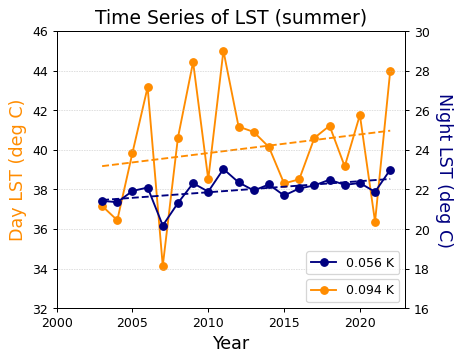

In [ ]:
value1 = df_temp['LST_Day_1km' + '_sum'].values
value2 = df_temp['LST_Night_1km' + '_sum'].values

b1, a1 = estimate_coef(year2, value1)
b2, a2 = estimate_coef(year2, value2)

# create figure and axis objects with subplots()
fig,ax = plt.subplots(figsize = (5,4), dpi = 90)
# make a plot
ax.plot(year2, value1, color="darkorange", marker="o", label = "{0:.3f} K".format(a1))
ax.plot(year2, a1*year2 + b1,color="darkorange", ls = "--")
# set x-axis label
ax.set_xlabel("Year", fontsize = 14)
# set y-axis label
ax.set_ylabel("Day LST (deg C)", color="darkorange", fontsize=14)
ax.set_ylim(32, 46)

# twin object for two different y-axis on the sample plot
ax2=ax.twinx()
# make a plot with different y-axis using second axis object
ax2.plot(year2, value2, color="navy",marker="o", label = "{0:.3f} K".format(a2))
ax2.plot(year2, a2*year2 + b2,color="navy", ls = "--")
ax2.set_ylabel("Night LST (deg C)",color="navy",fontsize=14, rotation = 270, va = "bottom")
ax2.set_ylim(16, 30)
plt.grid(ls = ":", lw = 0.5)
ax.legend(loc='lower right', bbox_to_anchor=(1,0))
ax2.legend(loc='lower right', bbox_to_anchor=(1,0.1))
plt.title("Time Series of LST (summer)", fontsize = 15)
plt.xlim(2000, 2023)

# plt.savefig("F:\\Heat_Island\\Plot\\Increase_{0}_total.png".format(field),
#            bbox_inches = "tight")

(2000.0, 2023.0)

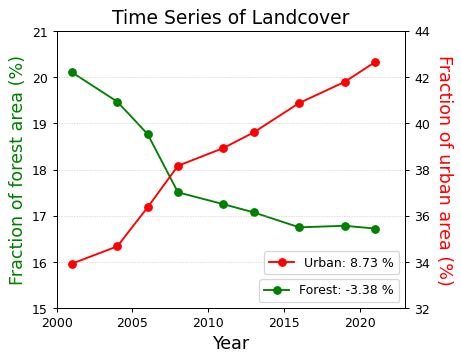

In [ ]:
field = 'LST_Day_1km'
value1 = df_lc["fr_green"].values
value2 = df_lc["fr_urban"].values

# b, a = estimate_coef(year2, value2)
# b_sum, a_sum = estimate_coef(year2, value2_sum)
# b_win, a_win = estimate_coef(year2, value2_win)

# create figure and axis objects with subplots()
fig,ax = plt.subplots(figsize = (5,4), dpi = 90)
# make a plot
ax.plot(year1, value1, color="g", marker="o", label = "Forest: {0:.2f} %".format(value1[-1] - value1[0]))
# set x-axis label
ax.set_xlabel("Year", fontsize = 14)
# set y-axis label
ax.set_ylabel("Fraction of forest area (%)", color="g", fontsize=14)
ax.set_ylim(15, 21)

# twin object for two different y-axis on the sample plot
ax2=ax.twinx()
# make a plot with different y-axis using second axis object
ax2.plot(year1, value2, color="r", marker="o", label = "Urban: {0:.2f} %".format(value2[-1] - value2[0]))
ax2.set_ylabel("Fraction of urban area (%)", color="r",fontsize=14, rotation = 270, va = "bottom")
ax2.set_ylim(32, 44)
plt.grid(ls = ":", lw = 0.5)

ax.legend(loc='lower right', bbox_to_anchor=(1,0))
ax2.legend(loc='lower right', bbox_to_anchor=(1,0.1))
plt.title("Time Series of Landcover", fontsize = 15)
plt.xlim(2000, 2023)

# plt.savefig("{folder}/Increase_green_{field}_total.png".format(field),
          #  bbox_inches = "tight")

In [ ]:
lc_tract = geemap.ee_to_df(tract)

# Annual changes of Land cover =========================================
nlcd = ee.ImageCollection("USGS/NLCD_RELEASES/2019_REL/NLCD")
nlcd2021 = ee.ImageCollection("USGS/NLCD_RELEASES/2021_REL/NLCD")
year1 = np.array([2001, 2004, 2006, 2008, 2011, 2013, 2016, 2019, 2021])

for y in tqdm(year1):
    if y != 2021:
      landcover = nlcd.filter(ee.Filter.eq('system:index', str(y))).first().select('landcover');
    else:
      landcover = nlcd2021.filter(ee.Filter.eq('system:index', str(y))).first().select('landcover');

#     urban = landcover.where(landcover.gt(20).and(landcover.lt(30)))
#     forest = landcover.where(landcover.gt(40).and(landcover.lt(50)))
    urban = landcover.expression("b('landcover') > 20 & b('landcover') < 30")
    green = landcover.expression("b('landcover') > 40 & b('landcover') < 50")

    total = landcover.reduceRegions(collection = tract, reducer = ee.Reducer.count(), scale = 30)
    urban = landcover.updateMask(urban).reduceRegions(collection = tract, reducer = ee.Reducer.count(), scale = 30)
    green = landcover.updateMask(green).reduceRegions(collection = tract, reducer = ee.Reducer.count(), scale = 30)

    tmp0 = geemap.ee_to_df(total)
    tmp1 = geemap.ee_to_df(urban)
    tmp2 = geemap.ee_to_df(green)

    lc_tract['total_{0}'.format(y)]  = tmp0['count']
    lc_tract['fr_urban_{0}'.format(y)]  = tmp1['count']
    lc_tract['fr_green_{0}'.format(y)]  = tmp2['count']

print("DONE")

# Annual changes of LST =========================================
for field in ['LST_Day_1km', 'LST_Night_1km']:
    print(field)

    temp_tract = geemap.ee_to_df(tract)
    col = ee.ImageCollection("MODIS/061/MYD11A2").select(field).filterDate('2000-01-01', '2026-01-01')
    year2 = np.arange(2003, 2023)

    for y in tqdm(year2):
        img = col.filterDate('{0}-01-01'.format(y), '{0}-01-01'.format(y+1)).mean() # annual mean
        img_sum = col.filterDate('{0}-06-01'.format(y), '{0}-09-01'.format(y)).mean() # summer mean
        img_win = col.filterDate('{0}-12-01'.format(y-1), '{0}-02-01'.format(y)).mean() # winter mean

        tmp = img.reduceRegions(collection = tract, reducer = ee.Reducer.mean(), scale = 1000)
        tmp_sum = img_sum.reduceRegions(collection = tract, reducer = ee.Reducer.mean(), scale = 1000)
        tmp_win = img_win.reduceRegions(collection = tract, reducer = ee.Reducer.mean(), scale = 1000)

        temp_tract['{0}_{1}'.format(field, y)]  = geemap.ee_to_df(tmp)['mean']*0.02
        temp_tract['{0}_sum{1}'.format(field, y)]  = geemap.ee_to_df(tmp_sum)['mean']*0.02
        temp_tract['{0}_win{1}'.format(field, y)]  = geemap.ee_to_df(tmp_win)['mean']*0.02

    tract_data = lc_tract.join(temp_tract.loc[:,temp_tract.keys()[12:]])
    tract_data.to_csv(f"{folder}/{field}_tract_2002-2022.csv")

    print("DONE")

100%|██████████| 9/9 [01:51<00:00, 12.43s/it]


DONE
LST_Day_1km


100%|██████████| 20/20 [02:41<00:00,  8.08s/it]


DONE
LST_Night_1km


100%|██████████| 20/20 [02:27<00:00,  7.39s/it]

DONE


In [ ]:
def estimate_coef(x, y):
    # number of observations/points
    n = np.size(x)

    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)

    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x

    # calculating regression coefficients
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x

    return (b_0, b_1)

field = 'LST_Day_1km'
tract_increase = geemap.ee_to_df(tract)
tract_data = pd.read_csv(f"{folder}/{field}_tract_2002-2022.csv", index_col = 0)

for idx in tqdm(range(0, len(lc_tract))):

    value1 = []
    for y in year1:
        value1.append(lc_tract.loc[idx, f'fr_urban_{y}'] / lc_tract.loc[idx, f'total_{y}'] * 100)

    value2, value2_sum, value2_win = [], [], []
    for y in year2:
        value2.append(tract_data.loc[idx, f'{field}_{y}'])
        value2_sum.append(tract_data.loc[idx, f'{field}_sum{y}'])
        value2_win.append(tract_data.loc[idx, f'{field}_win{y}'])

    b, a = estimate_coef(year2, value2)
    b_sum, a_sum = estimate_coef(year2, value2_sum)
    b_win, a_win = estimate_coef(year2, value2_win)

    tract_increase.loc[idx, "urban"] = value1[-1] - value1[0]
    tract_increase.loc[idx, "LST"] = a
    tract_increase.loc[idx, "LST_sum"] = a_sum
    tract_increase.loc[idx, "LST_win"] = a_win

    '''
    # create figure and axis objects with subplots()
    fig,ax = plt.subplots()
    # make a plot
    ax.plot(year1, value1, color="red", marker="o", label = "{0:.2f} %".format(value1[-1] - value1[0]))
    # set x-axis label
    ax.set_xlabel("year", fontsize = 14)
    # set y-axis label
    ax.set_ylabel("Fraction of urban area (%)", color="red", fontsize=14)
#     ax.set_ylim(63, 67)

    # twin object for two different y-axis on the sample plot
    ax2=ax.twinx()
    # make a plot with different y-axis using second axis object
    ax2.plot(year2, value2,color="blue",marker="o", label = "{0:.2f} K".format(a))

    ax2.plot(year2, a*year2 + b,color="blue", ls = "--")
    ax2.set_ylabel("LST (K)",color="blue",fontsize=14, rotation = 270, va = "bottom")
#     ax2.set_ylim(302, 310)
    plt.grid(ls = ":", lw = 0.5)
    ax.legend(loc='lower right', bbox_to_anchor=(1,0))
    ax2.legend(loc='lower right', bbox_to_anchor=(1,0.1))
    plt.title("TRACT: " + str(temp_tract.loc[idx, "GEOID"]))
    plt.savefig(f"{folder}/Increase_{field}_{temp_tract.loc[idx, "GEOID"]}.png", bbox_inches = "tight")
    plt.close()
    '''

tract_increase.to_csv(f"{folder}/{field}_increase_SA_2002-2022.csv")

100%|██████████| 375/375 [00:01<00:00, 315.24it/s]


LST_Day_1km


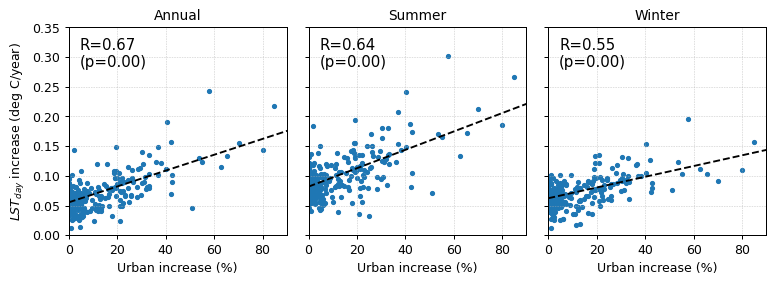

In [ ]:
field = 'LST_Day_1km'
print(field)
tract_increase = pd.read_csv(f"{folder}/{field}_increase_SA_2002-2022.csv", index_col = 0)
x = np.arange(0, 100)

fig, ax = plt.subplots(1,3, figsize = (10,3), dpi = 90, sharey = True)
# plt.subplots_adjust(bottom=0.1, right=0.8, top=0.9)
plt.subplots_adjust(wspace=0.1, hspace=0.0)

r, p = stats.pearsonr(tract_increase["urban"], tract_increase["LST"])
ax[0].scatter(tract_increase["urban"], tract_increase["LST"], s=10, label = "R = {0:.2f}".format(r))
b, a = estimate_coef(tract_increase["urban"], tract_increase["LST"])
ax[0].plot(x, a*x+b, c = "k", ls = "--")
ax[0].set_xlabel("Urban increase (%)")
ax[0].set_ylabel("$LST_{day}$ increase (deg C/year)")
ax[0].set_title("Annual", fontsize = 11)
xmin, xmax = ax[0].set_xlim(0, 90)
ymin, ymax = ax[0].set_ylim(0, 0.35)
# ax[0].legend(loc = "upper left")
ax[0].text(xmin + (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.05, "R={0:.2f}\n(p={1:.2f})".format(r, p),
           va = "top", ha = "left", fontsize = 12)
ax[0].grid(ls = ":", lw = 0.5)

r, p = stats.pearsonr(tract_increase["urban"], tract_increase["LST_sum"])
ax[1].scatter(tract_increase["urban"], tract_increase["LST_sum"], s=10, label = "R = {0:.2f}".format(r))
b, a = estimate_coef(tract_increase["urban"], tract_increase["LST_sum"])
ax[1].plot(x, a*x+b, c = "k", ls = "--")
ax[1].set_xlabel("Urban increase (%)")
ax[1].set_title("Summer", fontsize = 11)
xmin, xmax = ax[1].set_xlim(0, 90)
ymin, ymax = ax[1].set_ylim(0, 0.35)
# ax[1].legend(loc = "upper left")
ax[1].text(xmin + (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.05, "R={0:.2f}\n(p={1:.2f})".format(r, p),
           va = "top", ha = "left", fontsize = 12)
ax[1].grid(ls = ":", lw = 0.5)

r, p = stats.pearsonr(tract_increase["urban"], tract_increase["LST_win"])
ax[2].scatter(tract_increase["urban"], tract_increase["LST_win"], s=10, label = "R = {0:.2f}".format(r))
b, a = estimate_coef(tract_increase["urban"], tract_increase["LST_win"])
ax[2].plot(x, a*x+b, c = "k", ls = "--")
ax[2].set_xlabel("Urban increase (%)")
ax[2].set_title("Winter", fontsize = 11)
xmin, xmax = ax[2].set_xlim(0, 90)
ymin, ymax = ax[2].set_ylim(0, 0.35)
# ax[2].legend(loc = "upper left")
ax[2].text(xmin + (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.05, "R={0:.2f}\n(p={1:.2f})".format(r, p),
           va = "top", ha = "left", fontsize = 12)
plt.grid(ls = ":", lw = 0.5)

In [ ]:
print(np.corrcoef(tract_increase["urban"], tract_increase["LST"]))
print(np.corrcoef(tract_increase["urban"], tract_increase["LST_sum"]))
print(np.corrcoef(tract_increase["urban"], tract_increase["LST_win"]))

[[1.         0.32824105]
 [0.32824105 1.        ]]
[[1.         0.52241955]
 [0.52241955 1.        ]]
[[1.         0.24427476]
 [0.24427476 1.        ]]


In [ ]:
tract_increase.sort_values("urban")

,ALAND,AWATER,COUNTYFP,FUNCSTAT,GEOID,INTPTLAT,INTPTLON,MTFCC,NAME,NAMELSAD,STATEFP,TRACTCE,urban,LST
296,1338553,0,029,S,48029150502,+29.3717614,-098.5254764,G5020,1505.02,Census Tract 1505.02,48,150502,-0.066979,0.085191
2,1976489,11034,029,S,48029110600,+29.4292110,-098.5078374,G5020,1106,Census Tract 1106,48,110600,-0.045351,0.069727
259,2181682,0,029,S,48029180400,+29.4626758,-098.5708715,G5020,1804,Census Tract 1804,48,180400,-0.041254,0.077704
36,3534331,4030,029,S,48029181100,+29.5263791,-098.5502751,G5020,1811,Census Tract 1811,48,181100,-0.025419,0.059853
192,1109505,27139,029,S,48029190501,+29.4603679,-098.5198886,G5020,1905.01,Census Tract 1905.01,48,190501,0.000000,0.078099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,2071053,1377,029,S,48029171919,+29.3915743,-098.6850980,G5020,1719.19,Census Tract 1719.19,48,171919,57.335069,0.149869
165,6757288,9136,029,S,48029181726,+29.5312744,-098.6945613,G5020,1817.26,Census Tract 1817.26,48,181726,62.659574,0.130895
166,8696577,46627,029,S,48029181729,+29.5261089,-098.7445249,G5020,1817.29,Census Tract 1817.29,48,181729,62.772746,0.172140
168,2752469,2369,029,S,48029181733,+29.5133501,-098.7135103,G5020,1817.33,Census Tract 1817.33,48,181733,80.065359,0.160663


In [ ]:
def estimate_coef(x, y):
    # number of observations/points
    n = np.size(x)

    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)

    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x

    # calculating regression coefficients
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x

    return (b_0, b_1)

# **Time series of *NIGHT* temperature changes (Aqua)**

We will see the temporal changes of surface temperatures around Bexar county area using MODIS temperature data.

Aqua passing time - 1:30 am

In [10]:
field = 'LST_Night_1km'

def create_df_roi(img):
    dt_list = img.reduceColumns(ee.Reducer.toList(2), ['date','temp']).values().get(0)
    df_dt = pd.DataFrame(dt_list.getInfo(), columns=['date', 'temp'])
    df_dt['date'] = pd.to_datetime(df_dt['date'])
    return df_dt

def temp_total(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=Bexar, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_high(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=d_high, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_low(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=d_low, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_forest(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=forest, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_crops(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=crops, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_shrub(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=shrub, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_wetland(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=wetland, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_road(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=road_buf, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_nroad(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=non_road, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

# MODIS Aqua Night data (1:30 am)
col = ee.ImageCollection("MODIS/061/MYD11A2").select(field).filterDate('2000-01-01', '2023-01-01')

img_total = col.map(temp_total)
img_d_high = col.map(temp_d_high)
img_d_low = col.map(temp_d_low)
img_forest = col.map(temp_forest)
img_crops = col.map(temp_crops)
img_shrub = col.map(temp_shrub)
img_wetland = col.map(temp_wetland)
img_road = col.map(temp_road)
img_nroad = col.map(temp_nroad)

# Total temperautre
df = create_df_roi(img_total)
df["month"] = pd.DatetimeIndex(df['date']).month
df["year"] = pd.DatetimeIndex(df['date']).year

# Temperature for each region
df_d_high = create_df_roi(img_d_high)
df_d_low = create_df_roi(img_d_low)
df_forest = create_df_roi(img_forest)
df_crops = create_df_roi(img_crops)
df_shrub = create_df_roi(img_shrub)
df_wetland = create_df_roi(img_wetland)
df_road = create_df_roi(img_road)
df_nroad = create_df_roi(img_nroad)

df = df.join(df_d_high.set_index("date"), on="date", lsuffix='', rsuffix='_dhi')
df = df.join(df_d_low.set_index("date"), on="date", lsuffix='', rsuffix='_dlo')
df = df.join(df_forest.set_index("date"), on="date", lsuffix='', rsuffix='_for')
df = df.join(df_shrub.set_index("date"), on="date", lsuffix='', rsuffix='_shr')
df = df.join(df_crops.set_index("date"), on="date", lsuffix='', rsuffix='_cro')
df = df.join(df_wetland.set_index("date"), on="date", lsuffix='', rsuffix='_wet')
df = df.join(df_road.set_index("date"), on="date", lsuffix='', rsuffix='_rd')
df = df.join(df_nroad.set_index("date"), on="date", lsuffix='', rsuffix='_nrd')

df.to_csv(f"{folder}/{field}_SA_2002-2022.csv")

df

,date,temp,month,year,temp_dhi,temp_dlo,temp_for,temp_shr,temp_cro,temp_wet,temp_rd,temp_nrd
0,2002-07-04,295.398686,7,2002,295.651699,295.912294,293.830308,295.549372,295.440000,296.40,295.658091,295.163191
1,2002-07-12,289.683592,7,2002,287.932879,290.945426,282.436566,289.926013,291.072795,292.42,289.316752,289.931310
2,2002-07-20,295.450352,7,2002,295.610639,295.720000,294.460000,295.580000,295.560000,295.44,295.671226,295.232737
3,2002-07-28,293.216250,7,2002,291.341089,291.789825,289.600000,293.661168,294.140000,292.44,293.101619,293.342060
4,2002-08-05,295.330738,8,2002,296.010790,296.360000,294.580000,295.270521,295.220000,296.10,295.609979,295.140000
...,...,...,...,...,...,...,...,...,...,...,...,...
936,2022-11-25,280.658896,11,2022,280.770435,280.980000,280.640000,280.600176,280.260000,280.56,280.840499,280.531599
937,2022-12-03,289.425377,12,2022,289.550491,289.720000,285.686177,290.701046,289.647373,286.26,290.046530,289.062288
938,2022-12-11,277.922964,12,2022,279.813598,279.929062,277.189716,277.282116,276.905290,278.80,278.415464,277.560002
939,2022-12-19,268.196642,12,2022,267.840515,268.160987,267.226667,268.556011,268.226563,267.66,268.313768,267.936052


In [11]:
field = 'LST_Night_1km'
df = pd.read_csv(f"{folder}/{field}_SA_2002-2022.csv", index_col = 0)
df['date'] = pd.to_datetime(df['date'])
df["year"] = pd.DatetimeIndex(df['date']).year
df

,date,temp,month,year,temp_dhi,temp_dlo,temp_for,temp_shr,temp_cro,temp_wet,temp_rd,temp_nrd
0,2002-07-04,295.398686,7,2002,295.651699,295.912294,293.830308,295.549372,295.440000,296.40,295.658091,295.163191
1,2002-07-12,289.683592,7,2002,287.932879,290.945426,282.436566,289.926013,291.072795,292.42,289.316752,289.931310
2,2002-07-20,295.450352,7,2002,295.610639,295.720000,294.460000,295.580000,295.560000,295.44,295.671226,295.232737
3,2002-07-28,293.216250,7,2002,291.341089,291.789825,289.600000,293.661168,294.140000,292.44,293.101619,293.342060
4,2002-08-05,295.330738,8,2002,296.010790,296.360000,294.580000,295.270521,295.220000,296.10,295.609979,295.140000
...,...,...,...,...,...,...,...,...,...,...,...,...
936,2022-11-25,280.658896,11,2022,280.770435,280.980000,280.640000,280.600176,280.260000,280.56,280.840499,280.531599
937,2022-12-03,289.425377,12,2022,289.550491,289.720000,285.686177,290.701046,289.647373,286.26,290.046530,289.062288
938,2022-12-11,277.922964,12,2022,279.813598,279.929062,277.189716,277.282116,276.905290,278.80,278.415464,277.560002
939,2022-12-19,268.196642,12,2022,267.840515,268.160987,267.226667,268.556011,268.226563,267.66,268.313768,267.936052


(-10.0, 55.0)

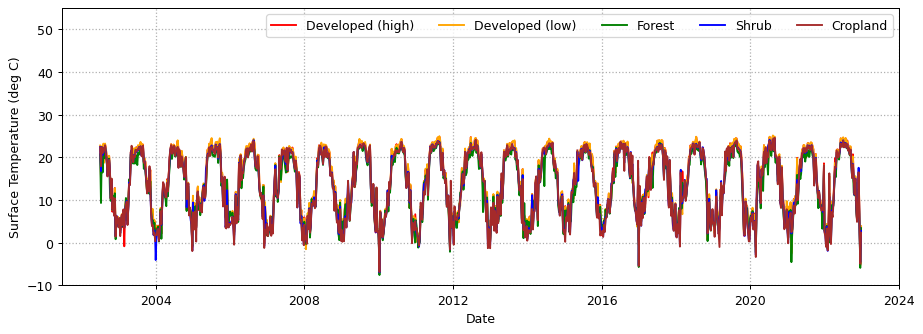

In [12]:
plt.subplots(1,1,figsize=(12,4), dpi = 90)
plt.plot(df['date'], df['temp_dhi']-273.15, label = "Developed (high)", color = "r")
plt.plot(df['date'], df['temp_dlo']-273.15, label = "Developed (low)", color = "orange")
plt.plot(df['date'], df['temp_for']-273.15, label = "Forest", color = "g")
plt.plot(df['date'], df['temp_shr']-273.15, label = "Shrub", color = "blue")
plt.plot(df['date'], df['temp_cro']-273.15, label = "Cropland", color = "brown")
# plt.plot(df['date'], df['temp_wet'], label = "Wetland", color = "blue")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend(ncol = 5)
plt.ylabel("Surface Temperature (deg C)")
plt.ylim(-10, 55)

(-8.0, 8.0)

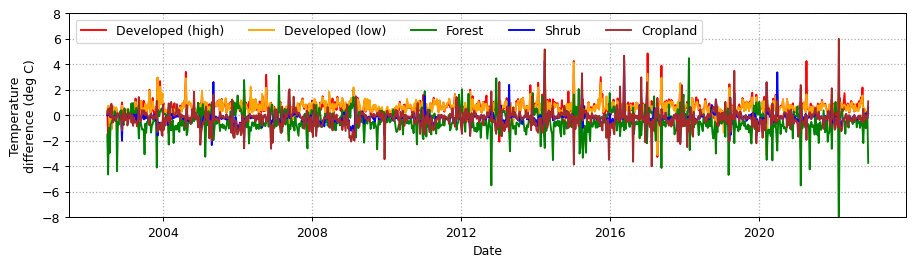

In [ ]:
plt.subplots(1,1,figsize=(12,3), dpi = 90)
plt.plot(df['date'], df['temp_dhi'] - df['temp'], label = "Developed (high)", color = "r")
plt.plot(df['date'], df['temp_dlo'] - df['temp'], label = "Developed (low)", color = "orange")
plt.plot(df['date'], df['temp_for'] - df['temp'], label = "Forest", color = "g")
plt.plot(df['date'], df['temp_shr'] - df['temp'], label = "Shrub", color = "blue")
plt.plot(df['date'], df['temp_cro'] - df['temp'], label = "Cropland", color = "brown")
# plt.plot(df['date'], df['temp_wet'] - df['temp'], label = "Wetland", color = "blue")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend(ncol = 5)
plt.ylabel("Temperature\ndifference (deg C)")
plt.ylim(-8, 8)

(-10.0, 55.0)

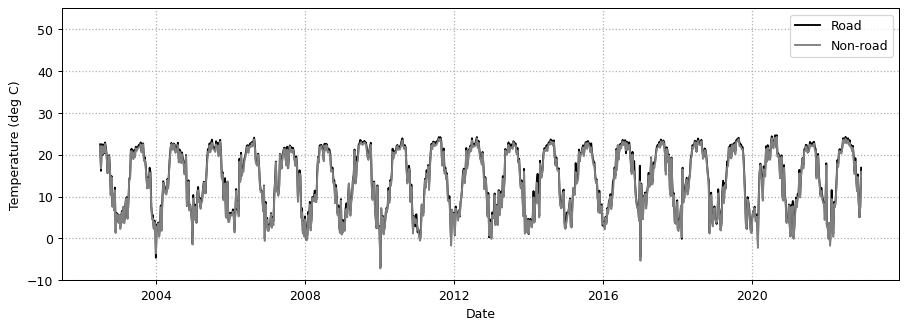

In [ ]:
plt.subplots(1,1,figsize=(12,4), dpi = 90)
plt.plot(df['date'], df['temp_rd']-273.15, label = "Road", color = "k")
plt.plot(df['date'], df['temp_nrd']-273.15, label = "Non-road", color = "gray")
# plt.plot(df['date'], df['temp_wet'], label = "Wetland", color = "blue")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend()
plt.ylabel("Temperature (deg C)")
plt.ylim(-10, 55)

(-8.0, 8.0)

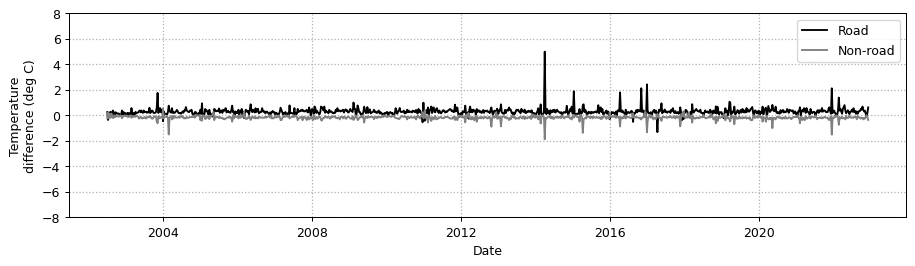

In [ ]:
plt.subplots(1,1,figsize=(12,3), dpi = 90)
plt.plot(df['date'], df['temp_rd'] - df['temp'], label = "Road", color = "k")
plt.plot(df['date'], df['temp_nrd'] - df['temp'], label = "Non-road", color = "gray")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend()
plt.ylabel("Temperature\ndifference (deg C)")
plt.ylim(-8, 8)

Text(0.5, 1.0, 'Annual')

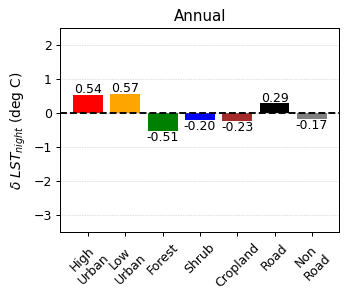

In [ ]:
idx = (df["month"] >= 0) & (df["month"] <= 12) # Total

def addlabels(x,y):
    for i in range(len(x)):
        if y[i] >= 0:
            plt.text(i, y[i]+0.05, "{0:.2f}".format(y[i]), ha = 'center')
        else:
            plt.text(i, y[i], "{0:.2f}".format(y[i]), ha = 'center', va = "top")

plt.subplots(1,1,figsize=(4,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx] - df['temp'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx] - df['temp'][idx]).mean(),
    'Forest': (df['temp_for'][idx] - df['temp'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx] - df['temp'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx] - df['temp'][idx]).mean(),
    'Road': (df['temp_rd'][idx] - df['temp'][idx]).mean(),
    'Non Road': (df['temp_nrd'][idx] - df['temp'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.xticks(rotation = 45)
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("$\delta$ $LST_{night}$ (deg C)", fontsize = 11)
plt.ylim(-3.5, 2.5)
plt.title("Annual")

Text(0.5, 1.0, 'Summer')

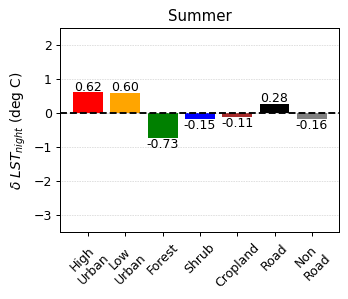

In [ ]:
idx = (df["month"] >= 6) & (df["month"] <= 8) # Summer

plt.subplots(1,1,figsize=(4,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx] - df['temp'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx] - df['temp'][idx]).mean(),
    'Forest': (df['temp_for'][idx] - df['temp'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx] - df['temp'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx] - df['temp'][idx]).mean(),
    'Road': (df['temp_rd'][idx] - df['temp'][idx]).mean(),
    'Non Road': (df['temp_nrd'][idx] - df['temp'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.xticks(rotation = 45)
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("$\delta$ $LST_{night}$ (deg C)", fontsize = 11)
plt.ylim(-3.5, 2.5)
plt.title("Summer")

Text(0.5, 1.0, 'Winter')

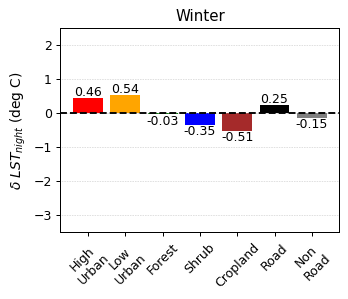

In [ ]:
idx = (df["month"] <= 2) | (df["month"] >= 12) # Winter

plt.subplots(1,1,figsize=(4,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx] - df['temp'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx] - df['temp'][idx]).mean(),
    'Forest': (df['temp_for'][idx] - df['temp'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx] - df['temp'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx] - df['temp'][idx]).mean(),
    'Road': (df['temp_rd'][idx] - df['temp'][idx]).mean(),
    'Non Road': (df['temp_nrd'][idx] - df['temp'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.xticks(rotation = 45)
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("$\delta$ $LST_{night}$ (deg C)", fontsize = 11)
plt.ylim(-3.5, 2.5)
plt.title("Winter")

In [ ]:
def estimate_coef(x, y):
    # number of observations/points
    n = np.size(x)

    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)

    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x

    # calculating regression coefficients
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x

    return (b_0, b_1)

tract_increase = geemap.ee_to_df(tract)
tract_data = pd.read_csv(f"{folder}/{field}_tract_2002-2022.csv", index_col = 0)

for idx in tqdm(range(0, len(lc_tract))):

    value1 = []
    for y in year1:
        value1.append(lc_tract.loc[idx, 'fr_urban_{0}'.format(y)] / lc_tract.loc[idx, 'total_{0}'.format(y)] * 100)

    value2, value2_sum, value2_win = [], [], []
    for y in range(2003, 2023):
        value2.append(temp_tract.loc[idx, f'{field}_{y}'])
        value2_sum.append(temp_tract.loc[idx, f'{field}_sum{y}'])
        value2_win.append(temp_tract.loc[idx, f'{field}_win{y}'])


    b, a = estimate_coef(year2, value2)
    b_sum, a_sum = estimate_coef(year2, value2_sum)
    b_win, a_win = estimate_coef(year2, value2_win)

    tract_increase.loc[idx, "urban"] = value1[-1] - value1[0]
    tract_increase.loc[idx, "LST"] = a
    tract_increase.loc[idx, "LST_sum"] = a_sum
    tract_increase.loc[idx, "LST_win"] = a_win

    '''
    # create figure and axis objects with subplots()
    fig,ax = plt.subplots()
    # make a plot
    ax.plot(year1, value1, color="red", marker="o", label = "{0:.2f} %".format(value1[-1] - value1[0]))
    # set x-axis label
    ax.set_xlabel("year", fontsize = 14)
    # set y-axis label
    ax.set_ylabel("Fraction of urban area (%)", color="red", fontsize=14)
#     ax.set_ylim(63, 67)

    # twin object for two different y-axis on the sample plot
    ax2=ax.twinx()
    # make a plot with different y-axis using second axis object
    ax2.plot(year2, value2,color="blue",marker="o", label = "{0:.2f} K".format(a))


    ax2.plot(year2, a*year2 + b,color="blue", ls = "--")
    ax2.set_ylabel("LST (K)",color="blue",fontsize=14, rotation = 270, va = "bottom")
#     ax2.set_ylim(302, 310)
    plt.grid(ls = ":", lw = 0.5)
    ax.legend(loc='lower right', bbox_to_anchor=(1,0))
    ax2.legend(loc='lower right', bbox_to_anchor=(1,0.1))
    plt.title("TRACT: " + str(temp_tract.loc[idx, "GEOID"]))
    plt.savefig("F:\\Heat_Island\\Plot\\Increase_{0}_{1}.png".format(field, temp_tract.loc[idx, "GEOID"]),
               bbox_inches = "tight")
    plt.close()
    '''

tract_increase.to_csv(f"{folder}/{field}_increase_SA_2002-2022.csv")

100%|██████████| 375/375 [00:02<00:00, 168.39it/s]


LST_Night_1km


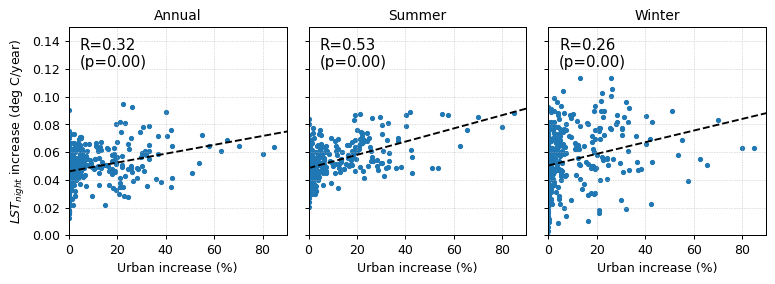

In [ ]:
field = 'LST_Night_1km'
print(field)
tract_increase = pd.read_csv(f"{folder}/{field}_increase_SA_2002-2022.csv".format(field), index_col = 0)
x = np.arange(0, 100)
fig, ax = plt.subplots(1,3, figsize = (10,3), dpi = 90, sharey = True)
# plt.subplots_adjust(bottom=0.1, right=0.8, top=0.9)
plt.subplots_adjust(wspace=0.1, hspace=0.0)

r, p = stats.pearsonr(tract_increase["urban"], tract_increase["LST"])
ax[0].scatter(tract_increase["urban"], tract_increase["LST"], s=10, label = "R = {0:.2f}".format(r))
b, a = estimate_coef(tract_increase["urban"], tract_increase["LST"])
ax[0].plot(x, a*x+b, c = "k", ls = "--")
ax[0].set_xlabel("Urban increase (%)")
ax[0].set_ylabel("$LST_{night}$ increase (deg C/year)")
ax[0].set_title("Annual", fontsize = 11)
xmin, xmax = ax[0].set_xlim(0, 90)
ymin, ymax = ax[0].set_ylim(0, 0.15)
# ax[0].legend(loc = "upper left")
ax[0].text(xmin + (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.05, "R={0:.2f}\n(p={1:.2f})".format(r, p),
           va = "top", ha = "left", fontsize = 12)
ax[0].grid(ls = ":", lw = 0.5)

r, p = stats.pearsonr(tract_increase["urban"], tract_increase["LST_sum"])
ax[1].scatter(tract_increase["urban"], tract_increase["LST_sum"], s=10, label = "R = {0:.2f}".format(r))
b, a = estimate_coef(tract_increase["urban"], tract_increase["LST_sum"])
ax[1].plot(x, a*x+b, c = "k", ls = "--")
ax[1].set_xlabel("Urban increase (%)")
ax[1].set_title("Summer", fontsize = 11)
xmin, xmax = ax[1].set_xlim(0, 90)
ymin, ymax = ax[1].set_ylim(0, 0.15)
# ax[1].legend(loc = "upper left")
ax[1].text(xmin + (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.05, "R={0:.2f}\n(p={1:.2f})".format(r, p),
           va = "top", ha = "left", fontsize = 12)
ax[1].grid(ls = ":", lw = 0.5)

r, p = stats.pearsonr(tract_increase["urban"], tract_increase["LST_win"])
ax[2].scatter(tract_increase["urban"], tract_increase["LST_win"], s=10, label = "R = {0:.2f}".format(r))
b, a = estimate_coef(tract_increase["urban"], tract_increase["LST_win"])
ax[2].plot(x, a*x+b, c = "k", ls = "--")
ax[2].set_xlabel("Urban increase (%)")
ax[2].set_title("Winter", fontsize = 11)
xmin, xmax = ax[2].set_xlim(0, 90)
ymin, ymax = ax[2].set_ylim(0, 0.15)
# ax[2].legend(loc = "upper left")
ax[2].text(xmin + (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.05, "R={0:.2f}\n(p={1:.2f})".format(r, p),
           va = "top", ha = "left", fontsize = 12)
plt.grid(ls = ":", lw = 0.5)

# **Day & Night temp differences**

In [13]:
## Add temperature differences
def add_diff(image):
    diff = image.select('LST_Day_1km').subtract(image.select('LST_Night_1km')).rename('LST_diff');
    return image.addBands(diff)

col = ee.ImageCollection("MODIS/061/MYD11A2").filterDate('2000-01-01', '2023-01-01')
withdiff = col.map(add_diff);

In [14]:
field = 'LST_diff'

def create_df_roi(img):
    dt_list = img.reduceColumns(ee.Reducer.toList(2), ['date','temp']).values().get(0)
    df_dt = pd.DataFrame(dt_list.getInfo(), columns=['date', 'temp'])
    df_dt['date'] = pd.to_datetime(df_dt['date'])
    return df_dt

def temp_total(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=Bexar, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_high(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=d_high, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_low(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=d_low, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_forest(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=forest, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_crops(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=crops, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_shrub(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=shrub, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_wetland(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=wetland, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_road(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=road_buf, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_nroad(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=non_road, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

# MODIS Aqua Day and Night LST difference (1:30 pm and 1:30 am)
col = withdiff.select(field)

img_total = col.map(temp_total)
img_d_high = col.map(temp_d_high)
img_d_low = col.map(temp_d_low)
img_forest = col.map(temp_forest)
img_crops = col.map(temp_crops)
img_shrub = col.map(temp_shrub)
img_wetland = col.map(temp_wetland)
img_road = col.map(temp_road)
img_nroad = col.map(temp_nroad)

# Total temperautre
df = create_df_roi(img_total)
df["month"] = pd.DatetimeIndex(df['date']).month
df["year"] = pd.DatetimeIndex(df['date']).year

# Temperature for each region
df_d_high = create_df_roi(img_d_high)
df_d_low = create_df_roi(img_d_low)
df_forest = create_df_roi(img_forest)
df_crops = create_df_roi(img_crops)
df_shrub = create_df_roi(img_shrub)
df_wetland = create_df_roi(img_wetland)
df_road = create_df_roi(img_road)
df_nroad = create_df_roi(img_nroad)

df = df.join(df_d_high.set_index("date"), on="date", lsuffix='', rsuffix='_dhi')
df = df.join(df_d_low.set_index("date"), on="date", lsuffix='', rsuffix='_dlo')
df = df.join(df_forest.set_index("date"), on="date", lsuffix='', rsuffix='_for')
df = df.join(df_shrub.set_index("date"), on="date", lsuffix='', rsuffix='_shr')
df = df.join(df_crops.set_index("date"), on="date", lsuffix='', rsuffix='_cro')
df = df.join(df_wetland.set_index("date"), on="date", lsuffix='', rsuffix='_wet')
df = df.join(df_road.set_index("date"), on="date", lsuffix='', rsuffix='_rd')
df = df.join(df_nroad.set_index("date"), on="date", lsuffix='', rsuffix='_nrd')

df.to_csv(f"{folder}/{field}_SA_2002-2022.csv")

df

,date,temp,month,year,temp_dhi,temp_dlo,temp_for,temp_shr,temp_cro,temp_wet,temp_rd,temp_nrd
0,2002-07-04,12.433968,7,2002,14.840642,14.094600,11.200137,12.030343,12.340589,13.36,13.303441,12.162888
1,2002-07-12,15.351038,7,2002,19.644183,15.723970,20.970472,14.183372,13.579291,16.90,15.849423,15.125469
2,2002-07-20,12.807627,7,2002,14.892405,14.392963,11.783363,12.107498,12.465444,14.28,13.564630,12.557001
3,2002-07-28,14.695735,7,2002,18.543801,17.784624,17.540000,13.309733,12.847798,17.60,15.074075,14.563872
4,2002-08-05,13.187378,8,2002,14.434380,13.208750,10.335872,13.691016,15.354571,17.82,14.076976,12.685175
...,...,...,...,...,...,...,...,...,...,...,...,...
934,2022-11-25,18.056270,11,2022,19.211561,18.289381,15.602683,18.427110,19.100000,20.58,18.396888,17.811948
935,2022-12-03,11.426499,12,2022,11.895575,10.352717,11.424946,10.926792,13.337778,NaN,11.195198,11.428075
936,2022-12-11,17.568437,12,2022,17.056883,15.908483,16.176679,18.315884,19.031429,19.06,17.571967,17.565711
937,2022-12-19,17.688268,12,2022,18.036024,18.321251,14.543241,18.312009,18.599507,21.28,18.040837,17.428325


In [15]:
field = 'LST_diff'
df = pd.read_csv(f"{folder}/{field}_SA_2002-2022.csv", index_col = 0)
df['date'] = pd.to_datetime(df['date'])
df["year"] = pd.DatetimeIndex(df['date']).year
df

,date,temp,month,year,temp_dhi,temp_dlo,temp_for,temp_shr,temp_cro,temp_wet,temp_rd,temp_nrd
0,2002-07-04,12.433968,7,2002,14.840642,14.094600,11.200137,12.030343,12.340589,13.36,13.303441,12.162888
1,2002-07-12,15.351038,7,2002,19.644183,15.723970,20.970472,14.183372,13.579291,16.90,15.849423,15.125469
2,2002-07-20,12.807627,7,2002,14.892405,14.392963,11.783363,12.107498,12.465444,14.28,13.564630,12.557001
3,2002-07-28,14.695735,7,2002,18.543801,17.784624,17.540000,13.309733,12.847798,17.60,15.074075,14.563872
4,2002-08-05,13.187378,8,2002,14.434380,13.208750,10.335872,13.691016,15.354571,17.82,14.076976,12.685175
...,...,...,...,...,...,...,...,...,...,...,...,...
934,2022-11-25,18.056270,11,2022,19.211561,18.289381,15.602683,18.427110,19.100000,20.58,18.396888,17.811948
935,2022-12-03,11.426499,12,2022,11.895575,10.352717,11.424946,10.926792,13.337778,NaN,11.195198,11.428075
936,2022-12-11,17.568437,12,2022,17.056883,15.908483,16.176679,18.315884,19.031429,19.06,17.571967,17.565711
937,2022-12-19,17.688268,12,2022,18.036024,18.321251,14.543241,18.312009,18.599507,21.28,18.040837,17.428325


Text(0.5, 1.0, '(a) Annual')

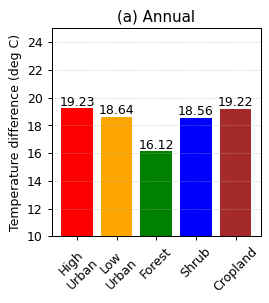

In [16]:
idx = (df["month"] >= 0) & (df["month"] <= 12) # Total

plt.subplots(1,1,figsize=(3,3), dpi = 90)

def addlabels(x,y):
    for i in range(len(x)):
        if y[i] >= 0:
            plt.text(i, y[i]+0.2, "{0:.2f}".format(y[i]), ha = 'center')
        else:
            plt.text(i, y[i], "{0:.2f}".format(y[i]), ha = 'center', va = "top")

mean_temp = {
    'High Urban': (df['temp_dhi'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx]).mean(),
    'Forest': (df['temp_for'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx]).mean(),
#     'Road': (df['temp_rd'][idx]).mean(),
#     'Non road': (df['temp_nrd'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.xticks(rotation = 45)
plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("Temperature difference (deg C)")
plt.ylim(10, 25)
plt.title("(a) Annual")

Text(0.5, 1.0, '(b) Summer')

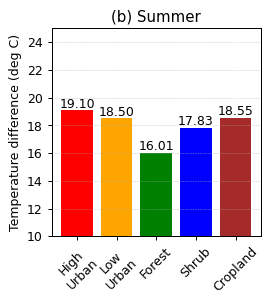

In [17]:
idx = (df["month"] >= 6) & (df["month"] <= 8) # Summer

plt.subplots(1,1,figsize=(3,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx]).mean(),
    'Forest': (df['temp_for'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx]).mean(),
#     'Road': (df['temp_rd'][idx]).mean(),
#     'Non road': (df['temp_nrd'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.xticks(rotation = 45)
plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("Temperature difference (deg C)")
plt.ylim(10, 25)
plt.title("(b) Summer")

Text(0.5, 1.0, '(c) Winter')

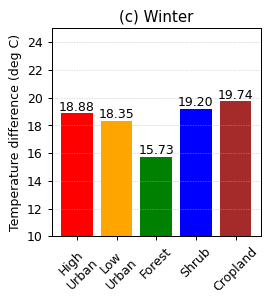

In [18]:
idx = (df["month"] <= 2) | (df["month"] >= 12) # Winter

plt.subplots(1,1,figsize=(3,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx]).mean(),
    'Forest': (df['temp_for'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx]).mean(),
#     'Road': (df['temp_rd'][idx]).mean(),
#     'Non road': (df['temp_nrd'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.xticks(rotation = 45)
plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("Temperature difference (deg C)")
plt.ylim(10, 25)
plt.title("(c) Winter")

In [ ]:
import ee
import geemap

Map = geemap.Map()
Map.centerObject(Bexar, 10)

visParams = {
  'min': 10,
  'max': 25,
  'palette': ['navy', 'blue', 'cyan', 'yellow', 'orange', 'red', 'brown'],
  'opacity': 0.8
};

Map.addLayer(withdiff.select("LST_diff").mean().clip(Bexar).multiply(0.02), visParams, "Day Temperature")

landcover = ee.Image('USGS/NLCD_RELEASES/2019_REL/NLCD/2019').select('landcover')
Map.addLayer(landcover.clip(Bexar), {}, 'NLCD Land Cover')
Map.add_legend(builtin_legend='NLCD')

vis_params = {
    'color': '000000',
    'pointSize': 3,
    'pointShape': 'circle',
    'width': 1,
    'lineType': 'solid',
    'fillColor': '00000000',
}

Map.addLayer(tract.style(**vis_params), {}, "Styled vector")

Map

### Last update: 10/12/2022
### Credited by YoungHyun Koo (kooala317@gmail.com)